In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/customer_purchase.csv")
df.head()

,customer_id,age,gender,annual_income,spending_score,purchased
0,1,56,Male,129779,74,Yes
1,2,46,Female,26168,7,No
2,3,32,Male,128099,33,No
3,4,25,Male,27561,23,No
4,5,38,Male,93794,85,Yes


In [3]:
# Structure of dataset
df.info()

# Statistical summary
df.describe()

# Shape (rows, columns)
df.shape

# Unique values in each column
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     500 non-null    int64 
 1   age             500 non-null    int64 
 2   gender          500 non-null    object
 3   annual_income   500 non-null    int64 
 4   spending_score  500 non-null    int64 
 5   purchased       500 non-null    object
dtypes: int64(4), object(2)
memory usage: 23.6+ KB


customer_id       500
age                42
gender              2
annual_income     500
spending_score     99
purchased           2
dtype: int64

In [4]:
# Check for missing values
df.isnull().sum()

customer_id       0
age               0
gender            0
annual_income     0
spending_score    0
purchased         0
dtype: int64

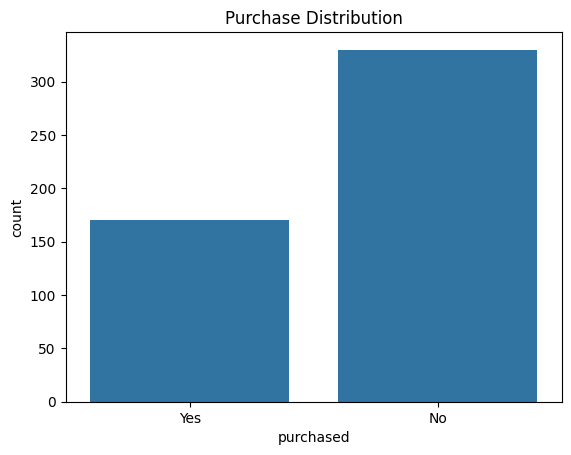

In [5]:
sns.countplot(x='purchased', data=df)
plt.title("Purchase Distribution")
plt.show()

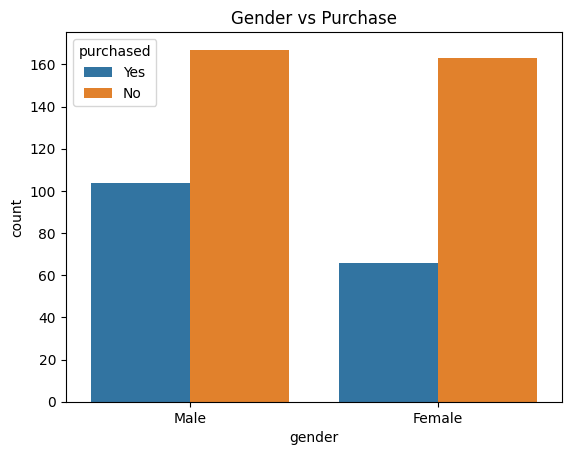

In [6]:
sns.countplot(x='gender', hue='purchased', data=df)
plt.title("Gender vs Purchase")
plt.show()

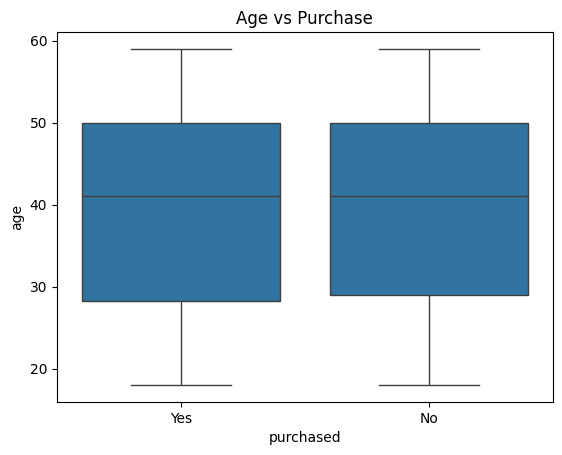

In [7]:
sns.boxplot(x='purchased', y='age', data=df)
plt.title("Age vs Purchase")
plt.show()

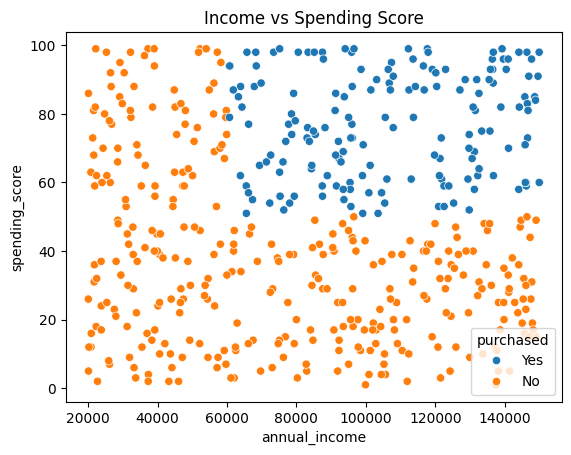

In [8]:
sns.scatterplot(
    x='annual_income',
    y='spending_score',
    hue='purchased',
    data=df
)
plt.title("Income vs Spending Score")
plt.show()

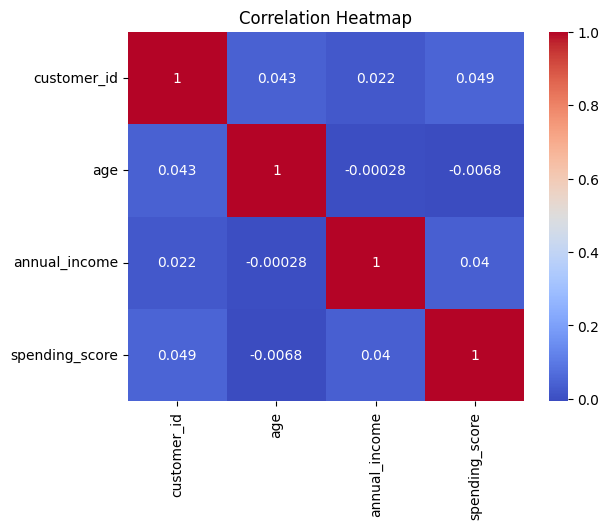

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['purchased'] = le.fit_transform(df['purchased'])

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features = ['age', 'annual_income', 'spending_score']
df[features] = scaler.fit_transform(df[features])

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(['customer_id', 'purchased'], axis=1)
y = df['purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.89
Random Forest Accuracy: 1.0


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       1.00      1.00      1.00        30

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



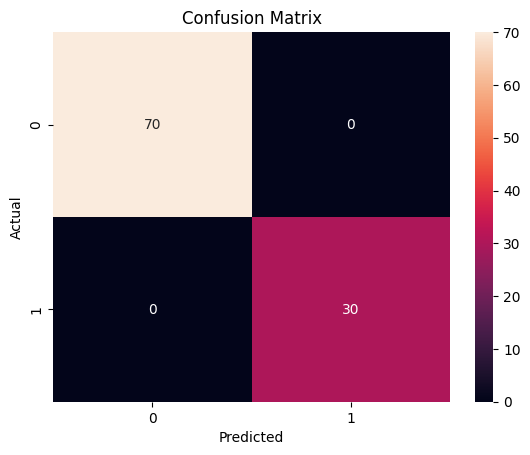

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

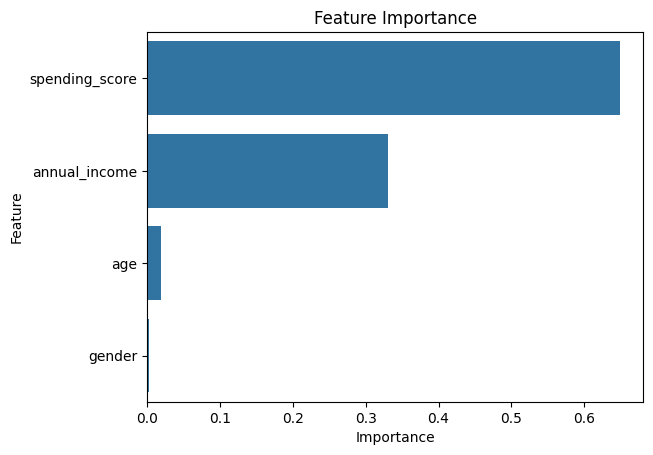

In [18]:
import pandas as pd

importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Feature Importance")
plt.show()

## ✅ Final Conclusion

- Random Forest performed best with highest accuracy
- Spending Score and Annual Income are key drivers of purchase
- Customers with high income & spending behavior are most likely to purchase

### 📊 Business Impact
- Target high-value customers
- Optimize marketing strategies
- Improve conversion rates